### **Introduction**

> This project is aimed to predict the price of used cars 

#### **Learn about the dataset (the cars)**

>Car name - Name and model of the car.

>Fuel type consumed - Ev, disel, petrol.

>Transmition - Cars transmition manual or automatic transmission.

>Selling type - seling type either the owner/ individual or the car dealer.

>Driven kilometers - Cars millage.

>Selling price - Final price/ sale of the car

>Present price - current price/ biding price
 
>Year - Manufucture of the car

#### **load the liblaries**

In [76]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

import warnings
warnings.filterwarnings('ignore')

#### **Load the data set**

In [77]:
df = pd.read_csv('car data.csv')
df.head(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


#### Check columns

In [78]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

#### Check for missing values

In [79]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

#### view structure of the dataset

In [80]:
print(df.shape)

(301, 9)


In [81]:
df.describe(include=object)

,Car_Name,Fuel_Type,Selling_type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [82]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


#### Check for duplicates

In [83]:
print(df.duplicated().sum())

2


#### Drop duplicates

In [84]:
df = df.drop_duplicates()

In [85]:
# confirmation
print(df.duplicated().sum())

0


#### Understanding the colum types

In [86]:
numerical_cols = df.select_dtypes(include =np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns :", numerical_cols)
print("Categorical_cols :", categorical_cols)

Numerical columns : ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']
Categorical_cols : ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


#### Analyize all the numrical columns

In [87]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,299.0,2013.615385,2.896868,2003.00,2012.00,2014.00,2016.00,2018.0
Selling_Price,299.0,4.589632,4.984240,0.10,0.85,3.51,6.00,35.0
Present_Price,299.0,7.541037,8.566332,0.32,1.20,6.10,9.84,92.6
Driven_kms,299.0,36916.752508,39015.170352,500.00,15000.00,32000.00,48883.50,500000.0
Owner,299.0,0.043478,0.248720,0.00,0.00,0.00,0.00,3.0


#### **Data visualization**

#### Histogram and kde plots for all numerical columns

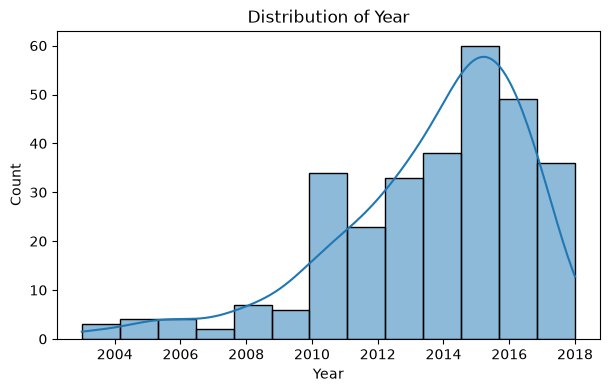

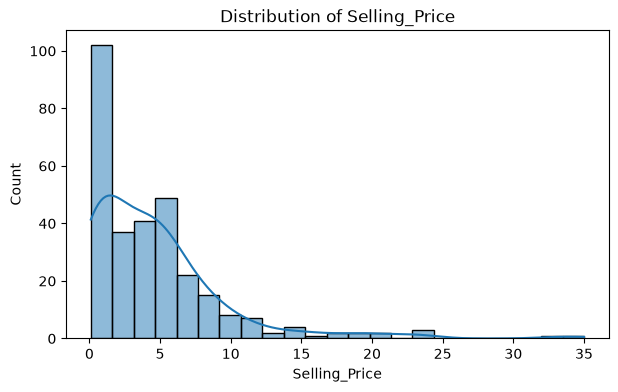

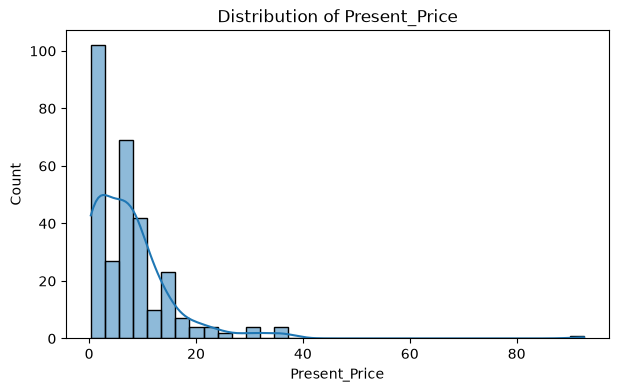

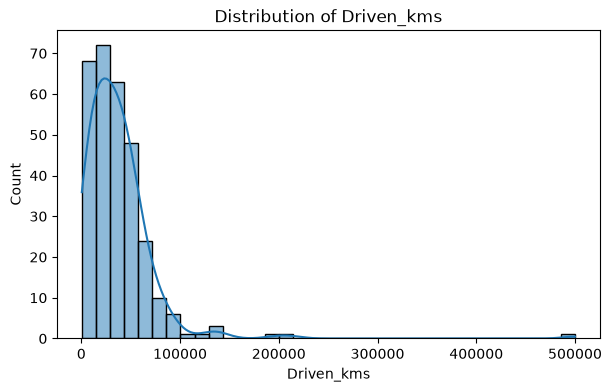

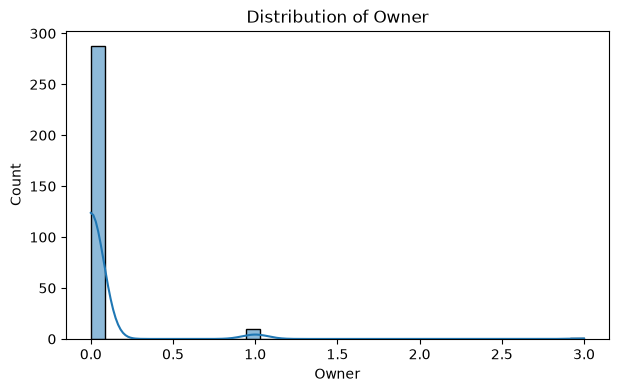

In [88]:
for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#### Box plot to detect outliers

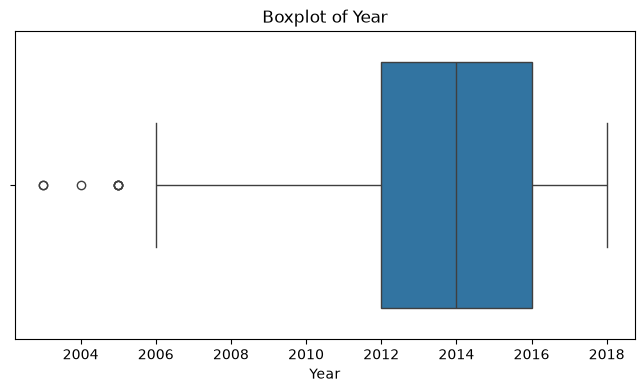

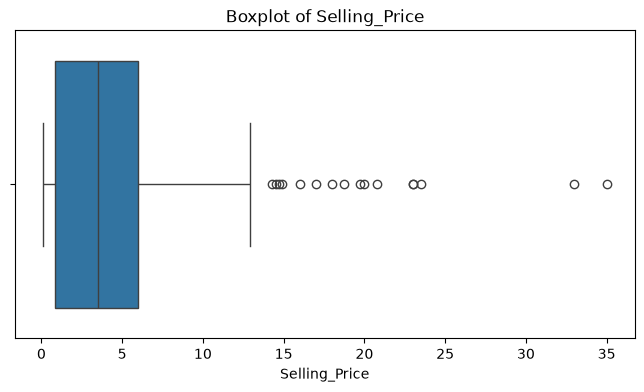

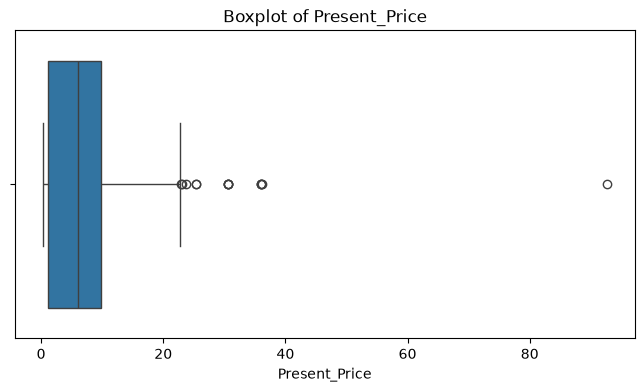

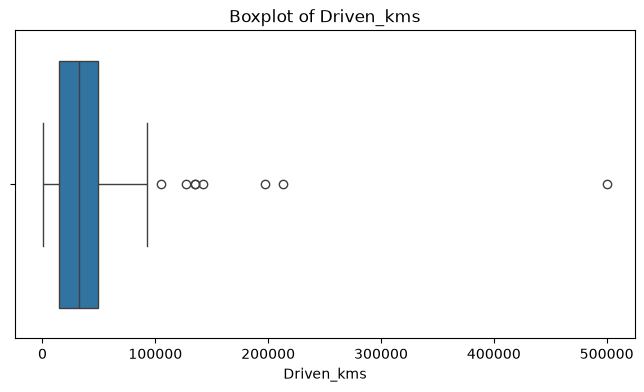

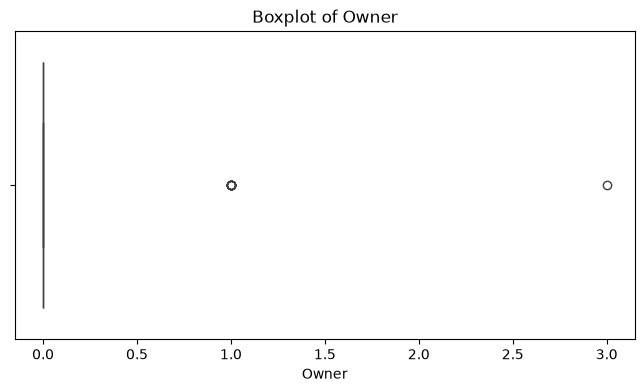

In [89]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

#### **skewness and koutosis**

In [90]:
print(df[numerical_cols].skew())
print(df[numerical_cols].kurtosis())

Year            -1.236876
Selling_Price    2.536522
Present_Price    4.189255
Driven_kms       6.418134
Owner            7.590605
dtype: float64
Year              1.507237
Selling_Price     9.482088
Present_Price    33.221336
Driven_kms       68.130422
Owner            72.821236
dtype: float64


#### Analyze categorical columns

In [91]:
for col in categorical_cols:
    print(df[col].value_counts())

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               10
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


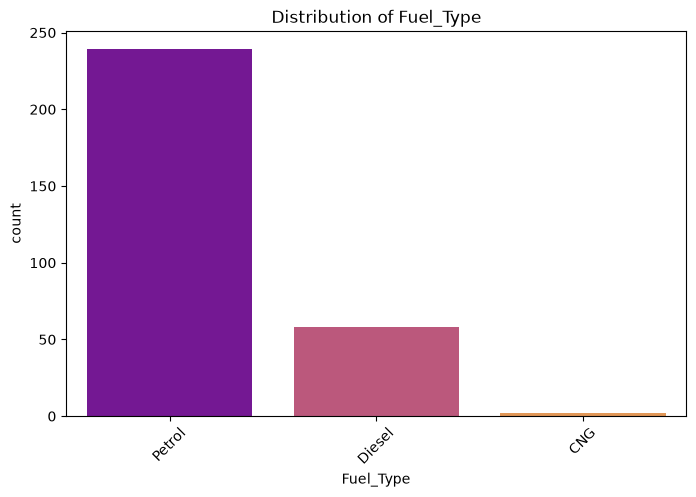

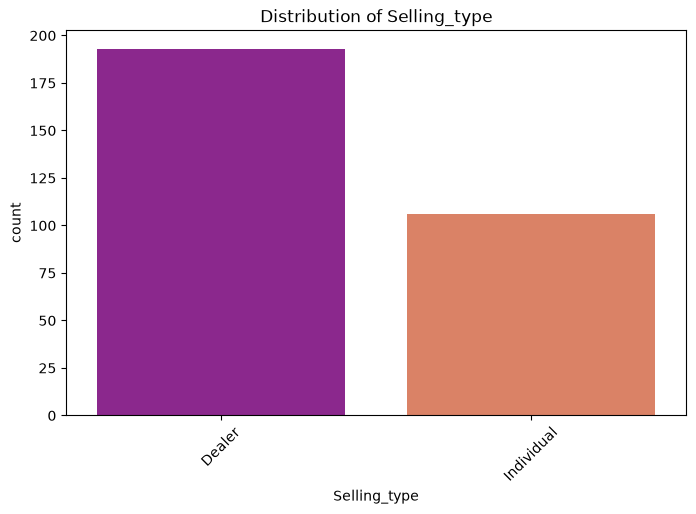

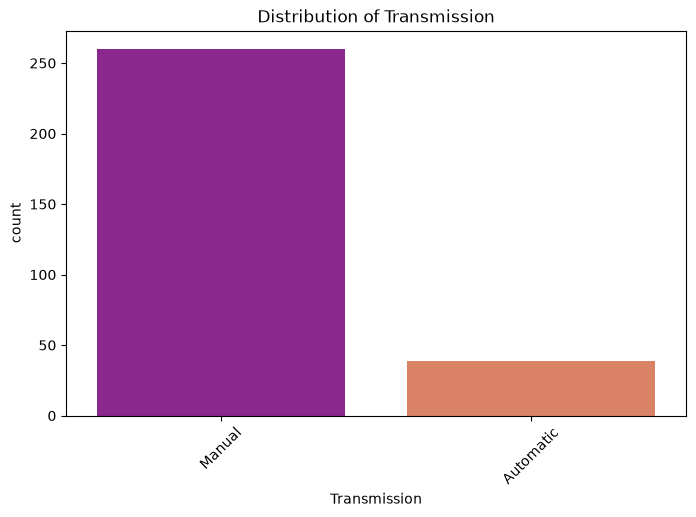

In [92]:
# count plot for all categorical values

# define the column we want to skip, in my case its car names, which will be ploted later
skip_cn = ['Car_Name']

for col in categorical_cols:
    if col in skip_cn:
        continue

    plt.figure(figsize=(8,5))
    sns.countplot(x=col, data=df, palette='plasma', hue=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

#### Horizontal plot for car model and price

In [93]:
# find the mean average of each car model
avg_sp = df.groupby('Car_Name')['Selling_Price'].mean().sort_values(ascending=False)

#### Check for car name brands

In [94]:
df['Car_Name'].unique().tolist()

['ritz',
 'sx4',
 'ciaz',
 'wagon r',
 'swift',
 'vitara brezza',
 's cross',
 'alto 800',
 'ertiga',
 'dzire',
 'alto k10',
 'ignis',
 '800',
 'baleno',
 'omni',
 'fortuner',
 'innova',
 'corolla altis',
 'etios cross',
 'etios g',
 'etios liva',
 'corolla',
 'etios gd',
 'camry',
 'land cruiser',
 'Royal Enfield Thunder 500',
 'UM Renegade Mojave',
 'KTM RC200',
 'Bajaj Dominar 400',
 'Royal Enfield Classic 350',
 'KTM RC390',
 'Hyosung GT250R',
 'Royal Enfield Thunder 350',
 'KTM 390 Duke ',
 'Mahindra Mojo XT300',
 'Bajaj Pulsar RS200',
 'Royal Enfield Bullet 350',
 'Royal Enfield Classic 500',
 'Bajaj Avenger 220',
 'Bajaj Avenger 150',
 'Honda CB Hornet 160R',
 'Yamaha FZ S V 2.0',
 'Yamaha FZ 16',
 'TVS Apache RTR 160',
 'Bajaj Pulsar 150',
 'Honda CBR 150',
 'Hero Extreme',
 'Bajaj Avenger 220 dtsi',
 'Bajaj Avenger 150 street',
 'Yamaha FZ  v 2.0',
 'Bajaj Pulsar  NS 200',
 'Bajaj Pulsar 220 F',
 'TVS Apache RTR 180',
 'Hero Passion X pro',
 'Bajaj Pulsar NS 200',
 'Yamaha Faz

##### Visualize the top 20 selling car brands

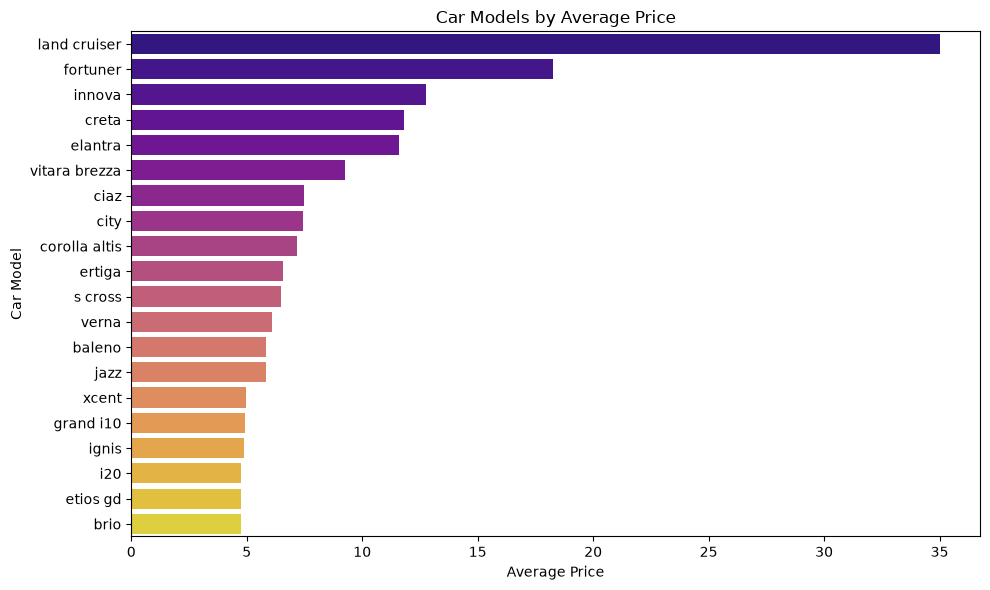

In [95]:
top_models = avg_sp.head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_models.values, y=top_models.index,
            palette='plasma', 
            hue=top_models.index,
            legend=False)
plt.title('Car Models by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

#### **Bivariate analysis**

In [96]:
# find the correlation between all numerical values
corr = df[numerical_cols].corr()
print(corr)

                   Year  Selling_Price  Present_Price  Driven_kms     Owner
Year           1.000000       0.234369      -0.053167   -0.525714 -0.181639
Selling_Price  0.234369       1.000000       0.876305    0.028566 -0.087880
Present_Price -0.053167       0.876305       1.000000    0.205224  0.009948
Driven_kms    -0.525714       0.028566       0.205224    1.000000  0.089367
Owner         -0.181639      -0.087880       0.009948    0.089367  1.000000


>visualizing our correlation heat map

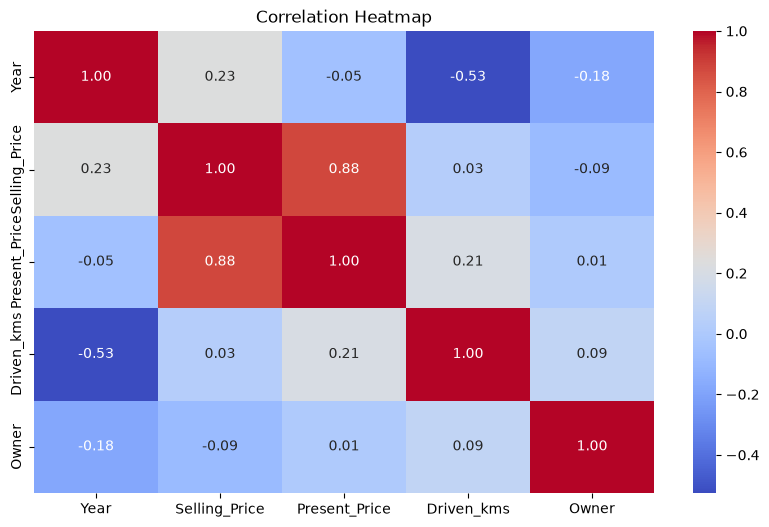

In [97]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

#### **Building Regression Models**

#### Import machine learning liblaries

In [98]:
#loading the liblaries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Cheking the data types to change it for our models

#### Create a new feature,{car's Age}

>The nortion behind finding the cars age, the models should learn the cars age to determine if its depreciation or appreciation.

>This avoids contradiction since the model does mot have to learn the calender dates to predict the price of the car, so in a case where we want to predict the future price of used cars our model might be contradicted on what to predict on unseen time

In [99]:
#Get the current time and date (incase of future dates)
from datetime import datetime
current_year =  datetime.now().year

In [100]:
# create the new feature car Age
df['car_age'] = current_year - df['Year']

In [101]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
car_age            int64
dtype: object

#### Convert our data types to objects from string

In [102]:
print(categorical_cols)

['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [103]:
df[categorical_cols] = df[categorical_cols].astype(object)

In [104]:
#confirmation
print(df.dtypes)

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
car_age            int64
dtype: object


>Define the target variable and the predictors

In [105]:
y = df["Selling_Price"] #Target variable
X = df.drop(columns=["Selling_Price","Present_Price", "Year"]) # droping values that might cause data leakage



#### Define the numerical and categorical columns

In [106]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

#### Split the Train Data to avoid leakage

In [107]:
# split the train data
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
)

#### Encoding our categorical values for the machine learning models

>Create a numerical pipeline to encode numerical values

In [ ]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [114]:
# one hot encoding
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "num_pipe", num_cols)
    ]
) 